In [48]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from peft import PeftModel
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Notebook is in /notebooks
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)

model_path = os.path.join(
    project_root,
    "models",
    "transformer",
    "araBERT_merged"
)

test_path = os.path.join(
    project_root,
    "data",
    "processed",
    "test.csv"
)

print("Model path:", model_path)
print("Exists:", os.path.exists(model_path))


Model path: d:\arabic-sentiment-analysis\models\transformer\araBERT_merged
Exists: True


In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    local_files_only=True
)

tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    local_files_only=True
)

device = torch.device("cpu")
model.to(device)
model.eval()
model.config.id2label = {
    0: "Positive",
    1: "Mixed",
    2: "Negative"
}

model.config.label2id = {
    "Positive": 0,
    "Mixed": 1,
    "Negative": 2
}
print("✓ Model loaded on CPU")


✓ Model loaded on CPU


In [6]:
id2label = model.config.id2label
label2id = model.config.label2id

print("id2label:", id2label)
print("label2id:", label2id)


id2label: {0: 'Positive', 1: 'Mixed', 2: 'Negative'}
label2id: {'Positive': 0, 'Mixed': 1, 'Negative': 2}


In [35]:
test_data = pd.read_csv("../data/processed/test.csv")

In [36]:
test_data.head()

,label,text
0,Mixed,عنوان جذاب ويخدع الناظر الي مضمونه المخيب للام...
1,Positive,جيد . الكيكة الساخنة عند الاستقبال.
2,Negative,مقبول . الافطار. صغر الفرف وزحمه المصعد
3,Positive,تحفة فنية تغوص في اعماق التاريخ و النفس البشرية
4,Positive,كتاب خفيف فكرتة بسيطة لكنه سهل ممتنع جمع ين شع...


In [37]:
test_data['label'].value_counts()

label
Positive    3428
Negative    3325
Mixed       3247
Name: count, dtype: int64

In [38]:
def convert_labels(df):
    # Handle different possible label formats
    label_mapping = {
        'positive': 0, 'Positive': 0, 'POSITIVE': 0,
        'mixed': 1, 'Mixed': 1, 'MIXED': 1,
        'negative': 2, 'Negative': 2, 'NEGATIVE': 2
    }
    df['label'] = df['label'].map(label_mapping)
    return df
test_data = convert_labels(test_data)

In [39]:
test_data.head()

,label,text
0,1,عنوان جذاب ويخدع الناظر الي مضمونه المخيب للام...
1,0,جيد . الكيكة الساخنة عند الاستقبال.
2,2,مقبول . الافطار. صغر الفرف وزحمه المصعد
3,0,تحفة فنية تغوص في اعماق التاريخ و النفس البشرية
4,0,كتاب خفيف فكرتة بسيطة لكنه سهل ممتنع جمع ين شع...


In [40]:
test_data =  test_data.iloc[:2000]  # Limit to first 2000 samples for quicker evaluation

In [41]:
text = test_data["text"].tolist()
labels = test_data["label"].tolist()

In [42]:
labels

[1,
 0,
 2,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 2,
 2,
 0,
 2,
 2,
 2,
 0,
 2,
 0,
 2,
 0,
 2,
 2,
 1,
 0,
 1,
 0,
 0,
 0,
 2,
 2,
 2,
 1,
 0,
 2,
 2,
 2,
 2,
 0,
 0,
 1,
 0,
 1,
 2,
 2,
 2,
 1,
 1,
 0,
 1,
 2,
 0,
 1,
 2,
 0,
 1,
 2,
 1,
 1,
 0,
 2,
 1,
 1,
 2,
 0,
 0,
 0,
 1,
 0,
 2,
 0,
 1,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 0,
 2,
 1,
 1,
 0,
 0,
 2,
 0,
 2,
 1,
 0,
 1,
 1,
 0,
 1,
 2,
 2,
 2,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 2,
 1,
 2,
 2,
 1,
 0,
 1,
 2,
 1,
 0,
 2,
 0,
 2,
 1,
 1,
 2,
 2,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 2,
 2,
 0,
 2,
 1,
 2,
 2,
 1,
 0,
 0,
 2,
 1,
 0,
 1,
 0,
 2,
 1,
 1,
 2,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 2,
 2,
 2,
 0,
 2,
 1,
 0,
 0,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 2,
 1,
 1,
 2,
 0,
 2,
 2,
 2,
 2,
 0,
 2,
 2,
 1,
 2,
 1,
 2,
 0,
 2,
 0,
 1,
 1,
 0,
 2,
 0,
 0,
 2,
 1,
 2,
 2,
 2,
 2,
 0,
 1,
 1,
 2,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 2,
 2,
 2,
 1,
 1,
 1,
 0,
 2,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 2,
 0,
 0,
 2,
 0,
 0,
 2,
 0,
 2,
 2,
 0,


In [43]:
text

['عنوان جذاب ويخدع الناظر الي مضمونه المخيب للامل او علي الاقل بالنسبة للعنوان. فالعنوان كفيل برسم علامات دهشة و رفع الحاجب .. لكن المحتوي بسيط مماجعل الكتاب مخيب للامل. ميزة الكتاب هو انه يحرك المخ .. في بعض الامور. ولكنه تنظير وتنظير باءس . امين معلوف يحاول ان يجد حلا للازمة الهوياتية التي يعاني منها بنو البشر .. باستخدام اسلوب باءس وهو علي هيءة:. يجب ان تصبح كذا لتصبح انسانا افضل .. دون بيان الكيف ز. عبر الصفحات يتكلم عن معضلة الهوية .. وهنا ميزة الكتاب .. ياخذ القاريء في جولة حول العالم ويغوص في سيكولوجية الانسان المتعنصر لهويته ولماذا هو هكذا . ياخذالقاريء في جولة حول الانظمة القاءمة حول العالم ويبين اخطاءها ويحملها مسءولية التطرف الموجود لدي الاقليات في الهوية سواء كانت دينية ام قومية ام تطرف للغة ..الخ . وهذا لوحده اعطاه نجوم برايي .. والحق يقال ابدع امين معلوف في هذه الزاوية .. وهذه الزاوية تستحق ويجب وبشدة ان يتم قراءة الكتاب لاجلها. اما سيءة الكتاب والتي تتجلي بوضوع في نصفه الثاني فهو انه يدعو الانظمة للتحاور حتي نصل الي تفاهم حول الازمة الهوياتية. باي خيال واي عالم من الاحلا

In [44]:
type(text[1])

str

In [45]:
def predict_batch(texts, batch_size=32):
    """Predict sentiment for multiple texts efficiently"""
    all_predictions = []
    all_confidences = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=192
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        predictions = logits.argmax(dim=-1).cpu().numpy()
        confidences = probabilities.max(dim=-1).values.cpu().numpy()

        all_predictions.extend(predictions)
        all_confidences.extend(confidences)
    
    return all_predictions, all_confidences

In [46]:
preds,confs = predict_batch(text, batch_size=32)

In [47]:
print("error analysis")
print("-"*50)
# print("f1 score:", f1_score(labels, preds, target_names=["positive", "neutral", "negative"]))
print("-"*30)
print("accuracy:", accuracy_score(labels, preds))
print("-"*30)
print("classification report:\n", classification_report(labels, preds, target_names=["positive", "neutral", "negative"]))
print("-"*30)
print("confusion matrix:\n", confusion_matrix(labels, preds))
print("-"*50)

error analysis
--------------------------------------------------
------------------------------
accuracy: 0.7675
------------------------------
classification report:
               precision    recall  f1-score   support

    positive       0.78      0.84      0.81       676
     neutral       0.70      0.67      0.69       658
    negative       0.82      0.79      0.80       666

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000

------------------------------
confusion matrix:
 [[565  87  24]
 [122 442  94]
 [ 35 103 528]]
--------------------------------------------------


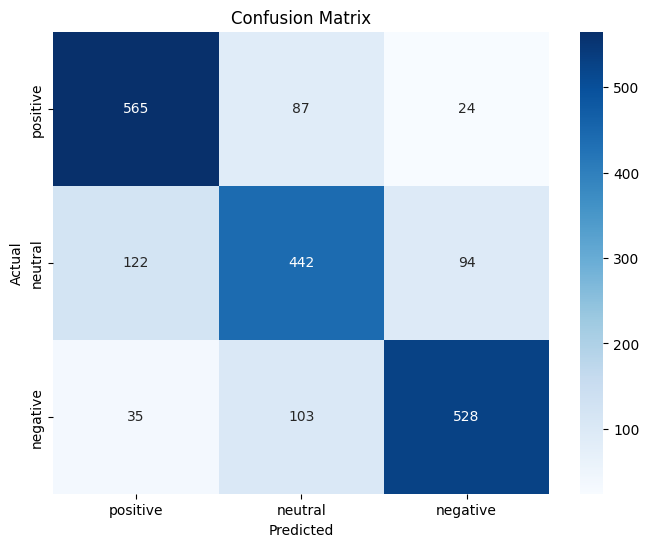

In [49]:
#confusion matrix plot
cn = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cn, annot=True, fmt='d', cmap='Blues', xticklabels=["positive", "neutral", "negative"], yticklabels=["positive", "neutral", "negative"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()